In [2]:
!pip install -U pandas numpy matplotlib scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: pandas
    Found existing installation: pand

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.impute import SimpleImputer

from scipy.spatial.distance import squareform  # to convert full distance matrix to condensed form


In [3]:
# graphichs
%matplotlib inline

# seed for repeatability
RANDOM_STATE = 42

# **1. Cluster Analysis**

# **1.1. kMeans / kModes / kPrototypes Clustering**

# Load data and select features (no feature engineering)

In [4]:
df = pd.read_excel('/content/fish_market_cleaned.xlsx')

In [5]:
# Drop target and any derived log_* columns: we only keep raw feature space for clustering
target_col = "Weight"
log_cols = [c for c in df.columns if c.startswith("log_")]

In [6]:
# X will contain both numeric and the single categorical 'Species'
X_raw = df.drop(columns=log_cols + [target_col]).copy()

In [7]:
# Identify column types (1 categorical + several numeric)
categorical_cols = [c for c in X_raw.columns if X_raw[c].dtype == "object"]
numeric_cols = [c for c in X_raw.columns if c not in categorical_cols]

In [8]:
display(df.head())
print("Categorical columns:", categorical_cols)
print("Numeric columns     :", numeric_cols)

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801


Categorical columns: ['Species']
Numeric columns     : ['Length1', 'Length2', 'Length3', 'Height', 'Width', 'Volume']


##  Minimal preprocessing: impute + scale + one‑hot
*HINT: do NOT engineer new features; we only make the data usable for k-means*

In [9]:
# Simple imputation: numeric -> mean, categorical -> most frequent
from sklearn.impute import SimpleImputer

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_proc = preprocess.fit_transform(X_raw)
print("Processed feature matrix shape:", X_proc.shape)

Processed feature matrix shape: (159, 13)


## Elbow curve (k=2..10) and pick best

In [12]:
k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_proc)
    inertias.append(km.inertia_)

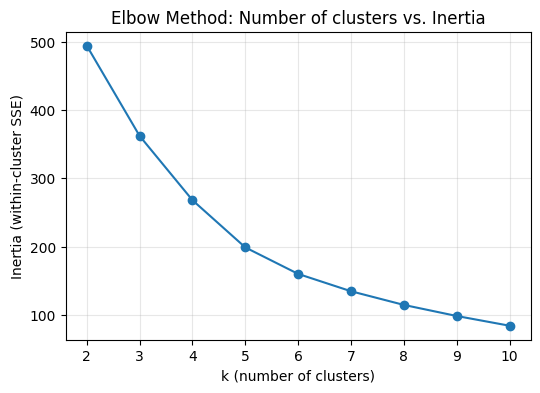

In [13]:
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method: Number of clusters vs. Inertia")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Simple knee heuristic: pick k after the largest relative drop
rel_drops = [(inertias[i-1] - inertias[i]) / inertias[i-1] for i in range(1, len(inertias))]
best_k = k_values[np.argmax(rel_drops) + 1]  # +1 for the shift
print(f"Selected k (heuristic) (approximately equal) ~ {best_k}")

Selected k (heuristic) (approximately equal) ~ 3


## Fit k‑Means with best k and output DataFrame

In [15]:
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_proc)

In [16]:
# Attach cluster labels back to original data frame
df_km = df.copy()
df_km["Cluster_kmeans"] = cluster_labels

In [17]:
print(f"k-means trained with k={best_k}.")
display(df_km.head())

k-means trained with k=3.


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,Cluster_kmeans
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0


In [27]:
# df_out.to_csv("kmeans_clusters_output.csv", index=False)

# **1.2. Hierarchical Clustering**

In [18]:
X_dense = X_proc.toarray() if hasattr(X_proc, "toarray") else X_proc
print("Processed feature matrix shape:", X_dense.shape)

Processed feature matrix shape: (159, 13)


## Euclidean: single, complete, ward dendrograms

In [19]:
Z_single_euclid   = linkage(X_dense, method="single",   metric="euclidean")
Z_complete_euclid = linkage(X_dense, method="complete", metric="euclidean")
Z_ward_euclid     = linkage(X_dense, method="ward")  # Ward assumes Euclidean

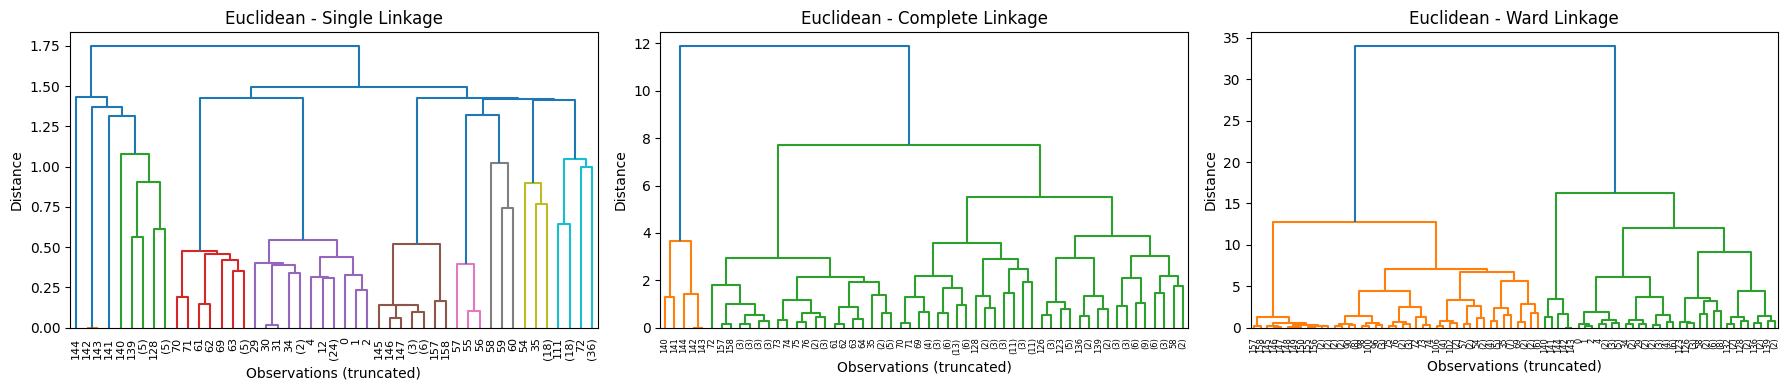

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, Z, title in zip(
    axes,
    [Z_single_euclid, Z_complete_euclid, Z_ward_euclid],
    ["Euclidean - Single Linkage", "Euclidean - Complete Linkage", "Euclidean - Ward Linkage"]
):
    dendrogram(Z, ax=ax, truncate_mode="level", p=6)
    ax.set_title(title)
    ax.set_xlabel("Observations (truncated)")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

* **Single** sometimes creates a chaining effect and can form long branches.
* **Complete** prefers more compact clusters.
* **Ward** minimizes the total intravariance; it generally gives stable results in our dataset.




## Gower distance for mixed-type data (average & complete)

In [21]:
def gower_distance_matrix(df_mix, cat_cols, num_cols):
    """
    Compute Gower distance for mixed-type data.
    Numeric features are range-normalized; categorical features use 0/1 mismatch.
    Returns a full (n x n) symmetric distance matrix with zeros on the diagonal.
    """
    n = df_mix.shape[0]
    num_arr = df_mix[num_cols].to_numpy(dtype=float)
    cat_arr = df_mix[cat_cols].astype(str).to_numpy()

    # Range normalization for numeric features
    ranges = num_arr.max(axis=0) - num_arr.min(axis=0)
    ranges[ranges == 0] = 1.0  # avoid division by zero

    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        diff_num = np.abs(num_arr[i] - num_arr) / ranges if num_arr.size else 0.0
        diff_cat = (cat_arr[i] != cat_arr).astype(float) if cat_arr.size else 0.0

        num_sum = diff_num.sum(axis=1) if isinstance(diff_num, np.ndarray) else 0.0
        cat_sum = diff_cat.sum(axis=1) if isinstance(diff_cat, np.ndarray) else 0.0

        m = len(num_cols) + len(cat_cols)
        D[i, :] = (num_sum + cat_sum) / m

    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    return D

In [22]:
D_gower = gower_distance_matrix(X_raw, categorical_cols, numeric_cols)
print("Gower distance matrix shape:", D_gower.shape)

Gower distance matrix shape: (159, 159)


In [23]:
# Convert full distance matrix to condensed form for scipy.linkage
D_gower_condensed = squareform(D_gower, checks=False)

# Average and Complete linkage on Gower distances
Z_avg_gower     = linkage(D_gower_condensed, method="average")   # metric implied by condensed distances
Z_complete_gower= linkage(D_gower_condensed, method="complete")

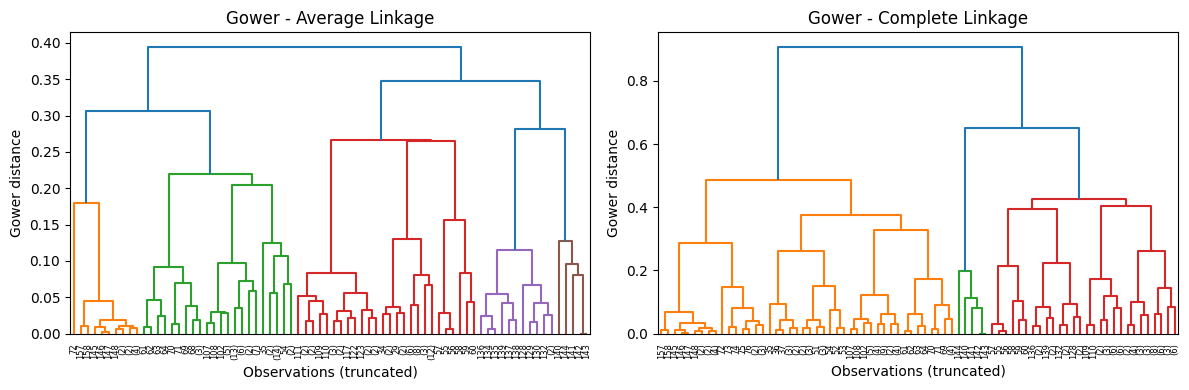

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, Z, title in zip(
    axes,
    [Z_avg_gower, Z_complete_gower],
    ["Gower - Average Linkage", "Gower - Complete Linkage"]
):
    dendrogram(Z, ax=ax, truncate_mode="level", p=6)
    ax.set_title(title)
    ax.set_xlabel("Observations (truncated)")
    ax.set_ylabel("Gower distance")
plt.tight_layout()
plt.show()

## Choose recommended k and output cluster assignments (DataFrame)

In [25]:
K_RECOMMENDED = 3  # adjust if needed

In [26]:
# fcluster with 'maxclust' so that we cut the tree into K_RECOMMENDED clusters
labels_single_euclid   = fcluster(Z_single_euclid,   t=K_RECOMMENDED, criterion="maxclust")
labels_complete_euclid = fcluster(Z_complete_euclid, t=K_RECOMMENDED, criterion="maxclust")
labels_ward_euclid     = fcluster(Z_ward_euclid,     t=K_RECOMMENDED, criterion="maxclust")

labels_avg_gower       = fcluster(Z_avg_gower,       t=K_RECOMMENDED, criterion="maxclust")
labels_complete_gower  = fcluster(Z_complete_gower,  t=K_RECOMMENDED, criterion="maxclust")

In [27]:
# Attach all labels to a single output DataFrame
df_hc = df.copy()
df_hc["HC_Single_Euclid"]    = labels_single_euclid
df_hc["HC_Complete_Euclid"]  = labels_complete_euclid
df_hc["HC_Ward_OneHot"]      = labels_ward_euclid
df_hc["HC_Average_Gower"]    = labels_avg_gower
df_hc["HC_Complete_Gower"]   = labels_complete_gower

print(f"Cluster assignments created with K={K_RECOMMENDED}.")
display(df_hc.head())

Cluster assignments created with K=3.


,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,HC_Single_Euclid,HC_Complete_Euclid,HC_Ward_OneHot,HC_Average_Gower,HC_Complete_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,2,3,3,2,3
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,2,3,3,2,3
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,2,3,3,2,3
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,2,3,3,2,3
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,2,3,3,2,3


In [42]:
df_hc.to_csv(f"hierarchical_clusters_K{K_RECOMMENDED}.csv", index=False)

# **1.3. DBScan Clustering **

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## DBSCAN hyperparameter search on Gower distance

In [29]:
# Define search grids
eps_grid = np.linspace(0.05, 0.35, 13)      # finer grid
min_samples_grid = [3, 4, 5, 6, 7, 8, 10]   # a few reasonable values

results = []
n = D_gower.shape[0]

[GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/)

[Look at again for exam](https://www.youtube.com/watch?v=RDZUdRSDOok)

In [30]:
for eps in eps_grid:
    for ms in min_samples_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(ms), metric='precomputed')
        labels = db.fit_predict(D_gower)

        # basic stats
        unique = np.unique(labels)
        clusters = [u for u in unique if u != -1]
        n_clusters = len(clusters)
        noise_ratio = (labels == -1).sum() / n

        # compute metrics on non-noise subset (silhouette with precomputed distances)
        sil = np.nan
        dbi = np.nan
        ch  = np.nan

        mask = labels != -1
        if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
            # Silhouette using precomputed Gower submatrix
            D_sub = D_gower[np.ix_(mask, mask)]
            sil = silhouette_score(D_sub, labels[mask], metric='precomputed')

            # Davies-Bouldin & Calinski-Harabasz require feature vectors; use X_proc subset
            # Assumes X_proc exists from previous steps (scaled numeric + one-hot categorical)
            try:
                dbi = davies_bouldin_score(X_proc[mask], labels[mask])
                ch  = calinski_harabasz_score(X_proc[mask], labels[mask])
            except Exception:
                pass

        results.append({
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": float(sil) if sil == sil else np.nan,
            "davies_bouldin": float(dbi) if dbi == dbi else np.nan,
            "calinski_harabasz": float(ch) if ch == ch else np.nan
        })

In [31]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(["silhouette"], ascending=False).head(10))

,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
6,0.050,10,5,0.270440,0.760323,0.576315,292.035554
5,0.050,8,5,0.238994,0.735678,0.622433,251.401994
3,0.050,6,7,0.125786,0.730459,0.633250,195.606613
4,0.050,7,6,0.176101,0.730373,0.646763,208.562015
1,0.050,4,8,0.088050,0.714787,0.620163,176.393571
2,0.050,5,8,0.088050,0.714787,0.620163,176.393571
13,0.075,10,5,0.220126,0.712797,0.680721,217.878968
0,0.050,3,9,0.069182,0.705647,0.603539,157.208981
12,0.075,8,6,0.081761,0.581238,1.021708,54.171866
11,0.075,7,6,0.069182,0.571130,1.040829,52.495310


## Select best configuration and fit final DBSCAN

In [32]:
# A practical selection rule:
# 1) at least 2 clusters
# 2) reasonable noise ratio (e.g., <= 0.5)
# 3) maximize silhouette
# 4) if tie, prefer n_clusters close to K ~ 3 from earlier steps

K_TARGET = 3

candidates = results_df[
    (results_df["n_clusters"] >= 2) &
    (results_df["noise_ratio"] <= 0.5) &
    (~results_df["silhouette"].isna())
].copy()

In [33]:
if candidates.empty:
    # Fallback: relax noise constraint
    candidates = results_df[~results_df["silhouette"].isna()].copy()

# Tie-break: score silhouette + small bonus if n_clusters == K_TARGET
candidates["score"] = candidates["silhouette"] + np.where(candidates["n_clusters"] == K_TARGET, 0.02, 0.0)

In [34]:
best_row = candidates.sort_values(["score", "silhouette"], ascending=False).iloc[0]
best_eps = float(best_row["eps"])
best_ms  = int(best_row["min_samples"])

print("Selected DBSCAN config -> eps:", best_eps, "| min_samples:", best_ms)
print("Stats -> n_clusters:", int(best_row["n_clusters"]),
      "| noise_ratio:", round(float(best_row["noise_ratio"]), 3),
      "| silhouette:", round(float(best_row["silhouette"]), 3))

Selected DBSCAN config -> eps: 0.05 | min_samples: 10
Stats -> n_clusters: 5 | noise_ratio: 0.27 | silhouette: 0.76


In [35]:
# Fit final DBSCAN with the chosen params
db_best = DBSCAN(eps=best_eps, min_samples=best_ms, metric='precomputed')
db_labels = db_best.fit_predict(D_gower)

In [36]:
db_best

DBSCAN(eps=0.05, metric='precomputed', min_samples=10)

In [37]:
db_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4])

In [38]:
# Attach to a copy of df
df_db = df.copy()
df_db["DBSCAN_Gower"] = db_labels
display(df_db.head())

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,DBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,0
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0


## HDBSCAN (Gower, precomputed)

In [39]:
import hdbscan

# HDBSCAN can accept precomputed distances. We pass the full Gower matrix.
# We'll try a small grid for min_cluster_size and min_samples.
mcs_grid = [5, 7, 10]     # min_cluster_size
ms_grid  = [1, 5, 7, 10]  # min_samples (0/None means default behavior)

hdb_results = []

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [40]:
for mcs in mcs_grid:
    for ms in ms_grid:
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs,
                              min_samples=ms,
                              metric='precomputed',
                              cluster_selection_method='eom')  # standard choice
        hdb_labels = hdb.fit_predict(D_gower)

        unique = np.unique(hdb_labels)
        clusters = [u for u in unique if u != -1]
        n_clusters = len(clusters)
        noise_ratio = (hdb_labels == -1).sum() / n

        sil = np.nan
        dbi = np.nan
        ch  = np.nan

        mask = hdb_labels != -1
        if mask.sum() >= 2 and len(np.unique(hdb_labels[mask])) >= 2:
            D_sub = D_gower[np.ix_(mask, mask)]
            sil = silhouette_score(D_sub, hdb_labels[mask], metric='precomputed')
            try:
                dbi = davies_bouldin_score(X_proc[mask], hdb_labels[mask])
                ch  = calinski_harabasz_score(X_proc[mask], hdb_labels[mask])
            except Exception:
                pass

        hdb_results.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": float(sil) if sil == sil else np.nan,
            "davies_bouldin": float(dbi) if dbi == dbi else np.nan,
            "calinski_harabasz": float(ch) if ch == ch else np.nan
        })

In [41]:
hdb_df = pd.DataFrame(hdb_results)
display(hdb_df.sort_values(["silhouette"], ascending=False).head(10))

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
3,5,10,7,0.106918,0.722780,0.660760,171.800362
7,7,10,7,0.106918,0.722780,0.660760,171.800362
6,7,7,7,0.069182,0.703241,0.740182,148.455778
2,5,7,7,0.069182,0.703241,0.740182,148.455778
10,10,7,7,0.069182,0.703241,0.740182,148.455778
1,5,5,7,0.056604,0.699805,0.783570,127.611246
9,10,5,7,0.056604,0.699805,0.783570,127.611246
5,7,5,7,0.056604,0.699805,0.783570,127.611246
8,10,1,7,0.037736,0.680176,0.834765,111.622077
4,7,1,9,0.050314,0.632792,0.727787,95.649468


In [42]:
# Pick the best HDBSCAN config
cand_hdb = hdb_df[
    (hdb_df["n_clusters"] >= 2) &
    (hdb_df["noise_ratio"] <= 0.5) &
    (~hdb_df["silhouette"].isna())
].copy()

In [43]:
if cand_hdb.empty:
    cand_hdb = hdb_df[~hdb_df["silhouette"].isna()].copy()

best_hdb = cand_hdb.sort_values(["silhouette"], ascending=False).iloc[0]
print("Selected HDBSCAN -> mcs:", int(best_hdb["min_cluster_size"]),
      "| ms:", int(best_hdb["min_samples"]))
print("Stats -> n_clusters:", int(best_hdb["n_clusters"]),
      "| noise_ratio:", round(float(best_hdb["noise_ratio"]), 3),
      "| silhouette:", round(float(best_hdb["silhouette"]), 3))


Selected HDBSCAN -> mcs: 5 | ms: 10
Stats -> n_clusters: 7 | noise_ratio: 0.107 | silhouette: 0.723


In [44]:
# Fit the best HDBSCAN to get final labels
hdb_best = hdbscan.HDBSCAN(min_cluster_size=int(best_hdb["min_cluster_size"]),
                           min_samples=int(best_hdb["min_samples"]),
                           metric='precomputed',
                           cluster_selection_method='eom')
hdb_labels = hdb_best.fit_predict(D_gower)


In [45]:
# Attach to df_db alongside DBSCAN
df_db["HDBSCAN_Gower"] = hdb_labels
display(df_db.head())

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume,DBSCAN_Gower,HDBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099,0,2
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041,0,2
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231,0,2
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410,0,2
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801,0,2


In [67]:
df_db.to_csv("dbscan_hdbscan_gower_labels.csv", index=False)

## Summary comparison

In [46]:
summary_rows = []

# Compute metrics helper
def compute_metrics_from_labels(labels, name):
    from collections import Counter
    unique = np.unique(labels)
    clusters = [u for u in unique if u != -1]
    n_clusters = len(clusters)
    noise_ratio = (labels == -1).sum() / len(labels)

    mask = labels != -1
    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
        sil = silhouette_score(D_gower[np.ix_(mask, mask)], labels[mask], metric='precomputed')
        dbi = davies_bouldin_score(X_proc[mask], labels[mask])
        ch  = calinski_harabasz_score(X_proc[mask], labels[mask])
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    summary_rows.append([name, n_clusters, noise_ratio, sil, dbi, ch])

# Evaluate both
compute_metrics_from_labels(df_db["DBSCAN_Gower"].to_numpy(), "DBSCAN (Gower)")
compute_metrics_from_labels(df_db["HDBSCAN_Gower"].to_numpy(), "HDBSCAN (Gower)")

summary_df = pd.DataFrame(summary_rows,
                          columns=["Method","#Clusters (excl. noise)","Noise ratio",
                                   "Silhouette (precomputed)","Davies-Bouldin","Calinski-Harabasz"])
display(summary_df.style.format({
    "Noise ratio":"{:.2f}",
    "Silhouette (precomputed)":"{:.3f}",
    "Davies-Bouldin":"{:.3f}",
    "Calinski-Harabasz":"{:.1f}"
}))

,Method,#Clusters (excl. noise),Noise ratio,Silhouette (precomputed),Davies-Bouldin,Calinski-Harabasz
0,DBSCAN (Gower),5,0.27,0.760,0.576,292.0
1,HDBSCAN (Gower),7,0.11,0.723,0.661,171.8


# **1.4. Clustering comparison methods**

## Prepare binary labels for external metrics

In [47]:
# target_col was defined before as weight

# Choose the threshold (limit_value): median is a robust default.
limit_value = df[target_col].median()
y_true = np.where(df[target_col] < limit_value, 1, 2)

print(f"limit_value for '{target_col}' = {limit_value:.3f}")
unique, counts = np.unique(y_true, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

limit_value for 'Weight' = 273.000
Class distribution: {np.int64(1): np.int64(79), np.int64(2): np.int64(80)}


The regression dataset does not have "true classes" for external metrics. As per the instructions, we generate binary classes by thresholding the target variable.

## Gather all cluster labels into a single DataFrame

In [48]:
# Start from the original df and attach the labels from previous steps.
df_all = df.copy()

In [49]:
# k-Means (from Section 1.1)
if "df_km" in globals() and "Cluster_kmeans" in df_km.columns:
    df_all["KMeans"] = df_km["Cluster_kmeans"]
else:
    raise RuntimeError("KMeans labels (df_km['Cluster_kmeans']) not found. Please run Section 1.1 cells.")

In [50]:
# Hierarchical (from Section 1.2)
if "df_hc" in globals():
    expected_hc_cols = ["HC_Single_Euclid", "HC_Complete_Euclid", "HC_Ward_OneHot",
                        "HC_Average_Gower", "HC_Complete_Gower"]
    for col in expected_hc_cols:
        if col in df_hc.columns:
            df_all[col] = df_hc[col]
        else:
            print(f"Warning: '{col}' not found in df_hc.")
else:
    raise RuntimeError("Hierarchical labels (df_hc[...]) not found. Please run Section 1.2 cells.")

In [51]:
# DBSCAN/HDBSCAN (from Section 1.3)
if "df_db" in globals():
    for col in ["DBSCAN_Gower", "HDBSCAN_Gower"]:
        if col in df_db.columns:
            df_all[col] = df_db[col]
        else:
            print(f"Warning: '{col}' not found in df_db.")
else:
    print("Note: df_db not found. If you didn't run DBSCAN/HDBSCAN, those columns will be missing.")

In [52]:
display(df_all.head())

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,...,log_Width,log_Volume,KMeans,HC_Single_Euclid,HC_Complete_Euclid,HC_Ward_OneHot,HC_Average_Gower,HC_Complete_Gower,DBSCAN_Gower,HDBSCAN_Gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,...,1.391282,9.780099,1,2,3,3,2,3,0,2
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,...,1.459917,9.888041,0,2,3,3,2,3,0,2
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,...,1.546732,9.888231,0,2,3,3,2,3,0,2
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,...,1.494139,10.148410,0,2,3,3,2,3,0,2
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,...,1.635885,10.170801,0,2,3,3,2,3,0,2


## Metric helpers (internal/external) with proper masking


In [53]:
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
)

In [54]:
def compute_internal_metrics(name, labels, X_proc, D_gower=None, metric_space="euclidean", noise_label=-1):
    """
    Compute internal validation metrics:
    - Silhouette: Euclidean on X_proc OR precomputed Gower on non-noise subset
    - Davies-Bouldin, Calinski-Harabasz: on X_proc (require feature vectors), non-noise subset if needed
    """
    import numpy as np
    metrics = {"Method": name, "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}

    labels = np.asarray(labels)
    # For density-based labels, we usually exclude noise (-1) for internal metrics.
    mask = labels != noise_label if noise_label in labels else np.ones_like(labels, dtype=bool)

    # Need at least 2 clusters among the considered points
    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
        # Silhouette
        if metric_space == "gower" and D_gower is not None:
            D_sub = D_gower[np.ix_(mask, mask)]
            metrics["Silhouette"] = silhouette_score(D_sub, labels[mask], metric="precomputed")
        else:
            metrics["Silhouette"] = silhouette_score(X_proc[mask], labels[mask])
        # DB & CH
        try:
            metrics["Davies-Bouldin"] = davies_bouldin_score(X_proc[mask], labels[mask])
            metrics["Calinski-Harabasz"] = calinski_harabasz_score(X_proc[mask], labels[mask])
        except Exception:
            pass

    return metrics

In [55]:
def compute_external_metrics(name, labels, y_true, noise_label=-1, exclude_noise=True):
    """
    Compute external validation metrics against y_true:
    - Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), Fowlkes-Mallows (FM)
    By default exclude noise (-1) to avoid artifacts on DBSCAN/HDBSCAN.
    """
    import numpy as np
    metrics = {"Method": name, "ARI": np.nan, "NMI": np.nan, "Fowlkes-Mallows": np.nan}

    labels = np.asarray(labels)
    y_arr = np.asarray(y_true)

    if exclude_noise and (noise_label in labels):
        mask = labels != noise_label
    else:
        mask = np.ones_like(labels, dtype=bool)

    if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2 and len(np.unique(y_arr[mask])) >= 2:
        metrics["ARI"] = adjusted_rand_score(y_arr[mask], labels[mask])
        metrics["NMI"] = normalized_mutual_info_score(y_arr[mask], labels[mask])
        metrics["Fowlkes-Mallows"] = fowlkes_mallows_score(y_arr[mask], labels[mask])

    return metrics

## Run metrics for all methods & build summary tables

In [56]:
method_specs = [
    ("KMeans",                   "KMeans",                "euclidean"),
    ("HC - Single (Euclid)",     "HC_Single_Euclid",      "euclidean"),
    ("HC - Complete (Euclid)",   "HC_Complete_Euclid",    "euclidean"),
    ("HC - Ward (OneHot)",       "HC_Ward_OneHot",        "euclidean"),
    ("HC - Average (Gower)",     "HC_Average_Gower",      "gower"),
    ("HC - Complete (Gower)",    "HC_Complete_Gower",     "gower"),
    ("DBSCAN (Gower)",           "DBSCAN_Gower",          "gower"),
    ("HDBSCAN (Gower)",          "HDBSCAN_Gower",         "gower"),
]

internal_rows = []
external_rows = []

In [57]:
for nice_name, col_name, space in method_specs:
    if col_name not in df_all.columns:
        # Method not available (e.g., you may have skipped DBSCAN/HDBSCAN)
        continue
    labels = df_all[col_name].to_numpy()

    # Internal metrics
    internal_rows.append(
        compute_internal_metrics(nice_name, labels, X_proc, D_gower=D_gower, metric_space=space, noise_label=-1)
    )
    # External metrics
    external_rows.append(
        compute_external_metrics(nice_name, labels, y_true, noise_label=-1, exclude_noise=True)
    )

In [58]:
internal_df = pd.DataFrame(internal_rows)
external_df = pd.DataFrame(external_rows)

In [59]:
print("Internal validation metrics:")
display(internal_df.style.format({"Silhouette":"{:.3f}","Davies-Bouldin":"{:.3f}","Calinski-Harabasz":"{:.1f}"}))

print("External validation metrics (noise excluded for density-based methods):")
display(external_df.style.format({"ARI":"{:.3f}","NMI":"{:.3f}","Fowlkes-Mallows":"{:.3f}"}))

Internal validation metrics:


,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.481,0.730,154.4
1,HC - Single (Euclid),0.242,1.321,43.1
2,HC - Complete (Euclid),0.316,0.748,85.7
3,HC - Ward (OneHot),0.479,0.707,149.8
4,HC - Average (Gower),0.456,1.012,134.2
5,HC - Complete (Gower),0.426,0.718,145.6
6,DBSCAN (Gower),0.760,0.576,292.0
7,HDBSCAN (Gower),0.723,0.661,171.8


External validation metrics (noise excluded for density-based methods):


,Method,ARI,NMI,Fowlkes-Mallows
0,KMeans,0.766,0.714,0.879
1,HC - Single (Euclid),0.192,0.192,0.577
2,HC - Complete (Euclid),0.181,0.304,0.629
3,HC - Ward (OneHot),0.711,0.626,0.851
4,HC - Average (Gower),0.611,0.541,0.791
5,HC - Complete (Gower),0.690,0.593,0.840
6,DBSCAN (Gower),0.352,0.474,0.597
7,HDBSCAN (Gower),0.267,0.396,0.520


In [65]:
# Merge for a single summary table if you like
summary_df = pd.merge(internal_df, external_df, on="Method", how="outer")
display(summary_df.style.format({
    "Silhouette":"{:.3f}","Davies-Bouldin":"{:.3f}","Calinski-Harabasz":"{:.1f}",
    "ARI":"{:.3f}","NMI":"{:.3f}","Fowlkes-Mallows":"{:.3f}"
}))

,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Fowlkes-Mallows
0,DBSCAN (Gower),0.760,0.576,292.0,0.352,0.474,0.597
1,HC - Average (Gower),0.456,1.012,134.2,0.611,0.541,0.791
2,HC - Complete (Euclid),0.316,0.748,85.7,0.181,0.304,0.629
3,HC - Complete (Gower),0.426,0.718,145.6,0.690,0.593,0.840
4,HC - Single (Euclid),0.242,1.321,43.1,0.192,0.192,0.577
5,HC - Ward (OneHot),0.479,0.707,149.8,0.711,0.626,0.851
6,HDBSCAN (Gower),0.723,0.661,171.8,0.267,0.396,0.520
7,KMeans,0.481,0.730,154.4,0.766,0.714,0.879


## Cluster–class cross-tabulation for each method

In [63]:
def cluster_class_crosstab(labels, y_true, method_name):
    """
    Produce a cross-tabulation (counts) of cluster vs. class.
    Includes noise as a separate row if present.
    """
    import pandas as pd
    tab = pd.crosstab(pd.Series(labels, name="Cluster"), pd.Series(y_true, name="Class"))
    print(f"\n=== {method_name}: Cluster–Class Crosstab ===")
    display(tab)
    return tab

In [64]:
crosstabs = {}
for nice_name, col_name, _ in method_specs:
    if col_name in df_all.columns:
        labels = df_all[col_name].to_numpy()
        crosstabs[nice_name] = cluster_class_crosstab(labels, y_true, nice_name)


=== KMeans: Cluster–Class Crosstab ===


Class,1,2
Cluster,,
0,0,67
1,79,7
2,0,6



=== HC - Single (Euclid): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
1,1,16
2,10,36
3,68,28



=== HC - Complete (Euclid): Cluster–Class Crosstab ===


...

Class,1,2
Cluster,,
1,75,7
2,0,5
3,4,68



=== DBSCAN (Gower): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
-1,16,27
0,1,31
1,17,1
2,31,3
3,0,18
4,14,0



=== HDBSCAN (Gower): Cluster–Class Crosstab ===


Class,1,2
Cluster,,
-1,7,10
0,1,12
1,14,0
2,1,34
3,7,1
4,18,1
5,31,4
6,0,18


## Simple interpretability checks

In [66]:
# Inspect how numeric features differ across clusters for a chosen method (e.g., KMeans)
inspect_method = "KMeans"  # change to another col, e.g., "HC_Ward_OneHot"
if inspect_method in df_all.columns:
    tmp = pd.concat([X_raw[numeric_cols], X_raw[categorical_cols], df_all[inspect_method]], axis=1)
    tmp = tmp.rename(columns={inspect_method: "Cluster"})
    print(f"\nNumeric feature means by cluster — {inspect_method}")
    display(tmp.groupby("Cluster")[numeric_cols].mean().round(2))
    if categorical_cols:
        cat = categorical_cols[0]
        print(f"\n{cat} distribution by cluster — {inspect_method}")
        display(pd.crosstab(tmp["Cluster"], tmp[cat]))


Numeric feature means by cluster — KMeans


,Length1,Length2,Length3,Height,Width,Volume
Cluster,,,,,,
0,33.32,36.05,40.02,12.71,5.80,50165.63
1,18.89,20.50,22.35,6.02,3.20,10360.94
2,52.68,56.52,60.33,9.55,6.38,184329.74



Species distribution by cluster — KMeans


Species,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
Cluster,,,,,,,
0,34,0,19,10,1,0,3
1,1,11,37,1,19,14,3
2,0,0,0,6,0,0,0


# **2. Dimensionality reduction**

# **2.1. PCA/MCA/FAMD**

In [67]:
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [68]:

# target_col = "Weight" --> was defined before
limit_value = df[target_col].median()
y_true = np.where(df[target_col] < limit_value, 1, 2)

In [69]:
# Prepare a color vector for plotly (cast to string for discrete color mapping)
y_color = pd.Series(y_true, name="Class").astype(str)

## PCA on numeric features

In [70]:
# Pipeline: numeric imputation + scaling, then PCA
num_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_num = num_prep.fit_transform(X_raw[numeric_cols])

In [71]:
# Fit PCA with as many components as numeric features to plot cumulative explained variance
n_num = len(numeric_cols)
pca_full = PCA(n_components=n_num, random_state=42)
X_pca_full = pca_full.fit_transform(X_num)

explained = pca_full.explained_variance_ratio_
cum_explained = explained.cumsum()

In [72]:
# Plot cumulative explained variance (scree-like) with plotly
pca_ev_df = pd.DataFrame({
    "n_components": np.arange(1, n_num + 1),
    "cumulative_explained_variance": cum_explained
})
fig_pca_cum = px.line(
    pca_ev_df, x="n_components", y="cumulative_explained_variance",
    title="PCA — Cumulative Explained Variance",
    markers=True
)
fig_pca_cum.update_yaxes(range=[0, 1])
fig_pca_cum.show()

In [73]:
# 2D PCA visualization (first 2 PCs)
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_num)
df_pca_2 = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
df_pca_2["Class"] = y_color.values

fig_pca_scatter = px.scatter(
    df_pca_2, x="PC1", y="PC2", color="Class",
    title=f"PCA (2 components) — Explained var: PC1={pca_2.explained_variance_ratio_[0]:.2f}, "
          f"PC2={pca_2.explained_variance_ratio_[1]:.2f}",
    opacity=0.85
)
fig_pca_scatter.show()

In [74]:
# 3D PCA visualization (first 3 PCs)
if n_num >= 3:
    pca_3 = PCA(n_components=3, random_state=42)
    X_pca_3 = pca_3.fit_transform(X_num)
    df_pca_3 = pd.DataFrame(X_pca_3, columns=["PC1", "PC2", "PC3"])
    df_pca_3["Class"] = y_color.values

    fig_pca_scatter3d = px.scatter_3d(
        df_pca_3, x="PC1", y="PC2", z="PC3", color="Class",
        title=("PCA (3 components) — Explained var: "
               f"PC1={pca_3.explained_variance_ratio_[0]:.2f}, "
               f"PC2={pca_3.explained_variance_ratio_[1]:.2f}, "
               f"PC3={pca_3.explained_variance_ratio_[2]:.2f}"),
        opacity=0.85
    )
    fig_pca_scatter3d.show()
else:
    print("Not enough numeric features for 3D PCA.")

## MCA on categorical features only

In [75]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 11.2 MB/s eta 0:00:00


*MCA on categorical-only data (2D/3D) with explained inertia*

In [84]:
import sys

try:
    import prince
except ImportError as e:
    print("The 'prince' package is required for MCA/FAMD. Install with: pip install prince")
    raise e

In [85]:
# Prepare categorical-only DataFrame
X_cat = X_raw[categorical_cols].copy()
for c in X_cat.columns:
    X_cat[c] = X_cat[c].astype("category")

In [86]:
# Fit MCA (up to 3 components)
mca = prince.MCA(n_components=3, random_state=42)
mca = mca.fit(X_cat)

In [87]:
# Get explained inertia with robust fallbacks
def get_mca_explained_inertia_safe(mca_obj):
    # Newer prince versions
    if hasattr(mca_obj, "explained_inertia_") and mca_obj.explained_inertia_ is not None:
        return list(mca_obj.explained_inertia_)
    # Older prince builds: compute from eigenvalues / total inertia
    if hasattr(mca_obj, "eigenvalues_") and getattr(mca_obj, "eigenvalues_", None) is not None \
       and hasattr(mca_obj, "total_inertia_") and mca_obj.total_inertia_:
        vals = np.array(mca_obj.eigenvalues_).flatten()
        total = float(mca_obj.total_inertia_)
        if total > 0 and vals.size > 0:
            return list((vals / total).tolist())
    # Fallback: return empty to signal N/A
    return []

In [88]:
mca_inertia = get_mca_explained_inertia_safe(mca)
print("MCA — explained inertia per component:",
      [f"{v:.4f}" for v in mca_inertia] if mca_inertia else "N/A")

MCA — explained inertia per component: ['0.1667', '0.1667', '0.1667']


In [89]:
# Row coordinates for plotting
mca_coords = mca.row_coordinates(X_cat)
mca_coords.columns = [f"MC{i+1}" for i in range(mca_coords.shape[1])]
mca_coords["Class"] = pd.Series(y_true, name="Class").astype(str).values

In [90]:
#2D scatter (MC1 vs MC2)
if {"MC1", "MC2"}.issubset(mca_coords.columns):
    mc1_exp = mca_inertia[0] if len(mca_inertia) >= 1 else np.nan
    mc2_exp = mca_inertia[1] if len(mca_inertia) >= 2 else np.nan
    title_2d = (f"MCA (2 components) — Explained inertia: MC1={mc1_exp:.2f}, MC2={mc2_exp:.2f}"
                if not np.isnan([mc1_exp, mc2_exp]).any()
                else "MCA (2 components) — Explained inertia: N/A")
    fig_mca_2d = px.scatter(
        mca_coords, x="MC1", y="MC2", color="Class",
        title=title_2d, opacity=0.85
    )
    fig_mca_2d.show()
else:
    print("Not enough categorical dimensions for 2D MCA.")

In [91]:
# 3D scatter (MC1, MC2, MC3) — may not be available with a single categorical feature
if {"MC1", "MC2", "MC3"}.issubset(mca_coords.columns):
    mc3_exp = mca_inertia[2] if len(mca_inertia) >= 3 else np.nan
    title_3d = (f"MCA (3 components) — Explained inertia: "
                f"MC1={mca_inertia[0]:.2f}, MC2={mca_inertia[1]:.2f}, MC3={mc3_exp:.2f}"
                if len(mca_inertia) >= 3 and not np.isnan(mc3_exp) else
                "MCA (3 components) — Explained inertia: N/A")
    fig_mca_3d = px.scatter_3d(
        mca_coords, x="MC1", y="MC2", z="MC3", color="Class",
        title=title_3d, opacity=0.85
    )
    fig_mca_3d.show()
else:
    print("Not enough categorical dimensions for 3D MCA (single categorical variable may limit dimensionality).")

## **FAMD on mixed-type data (2D/3D) with explained inertia**

In [92]:
# Prepare mixed-type DataFrame (numeric + categorical)
X_mixed = X_raw.copy()
for c in categorical_cols:
    X_mixed[c] = X_mixed[c].astype("category")

# Fit FAMD (up to 3 components)
famd = prince.FAMD(n_components=3, random_state=42)
famd = famd.fit(X_mixed)

In [93]:
# Get explained inertia with robust fallbacks
def get_famd_explained_inertia_safe(famd_obj):
    # Typical attribute
    if hasattr(famd_obj, "explained_inertia_") and famd_obj.explained_inertia_ is not None:
        return list(famd_obj.explained_inertia_)
    # Older builds: try eigenvalues / total inertia
    if hasattr(famd_obj, "eigenvalues_") and getattr(famd_obj, "eigenvalues_", None) is not None \
       and hasattr(famd_obj, "total_inertia_") and famd_obj.total_inertia_:
        vals = np.array(famd_obj.eigenvalues_).flatten()
        total = float(famd_obj.total_inertia_)
        if total > 0 and vals.size > 0:
            return list((vals / total).tolist())
    # Fallback: return empty to signal N/A
    return []

In [94]:
famd_inertia = get_famd_explained_inertia_safe(famd)
print("FAMD — explained inertia per component:",
      [f"{v:.4f}" for v in famd_inertia] if famd_inertia else "N/A")

FAMD — explained inertia per component: ['0.5983', '0.1291', '0.0670']


In [95]:
# Row coordinates for plotting
famd_coords = famd.row_coordinates(X_mixed)
famd_coords.columns = [f"F{i+1}" for i in range(famd_coords.shape[1])]
famd_coords["Class"] = pd.Series(y_true, name="Class").astype(str).values

In [96]:
# 2D scatter (F1 vs F2)
if {"F1", "F2"}.issubset(famd_coords.columns):
    f1_exp = famd_inertia[0] if len(famd_inertia) >= 1 else np.nan
    f2_exp = famd_inertia[1] if len(famd_inertia) >= 2 else np.nan
    title_2d = (f"FAMD (2 components) — Explained inertia: F1={f1_exp:.2f}, F2={f2_exp:.2f}"
                if not np.isnan([f1_exp, f2_exp]).any()
                else "FAMD (2 components) — Explained inertia: N/A")
    fig_famd_2d = px.scatter(
        famd_coords, x="F1", y="F2", color="Class",
        title=title_2d, opacity=0.85
    )
    fig_famd_2d.show()
else:
    print("Not enough dimensions for 2D FAMD.")

In [97]:
# 3D scatter (F1, F2, F3)
if {"F1", "F2", "F3"}.issubset(famd_coords.columns):
    f3_exp = famd_inertia[2] if len(famd_inertia) >= 3 else np.nan
    title_3d = (f"FAMD (3 components) — Explained inertia: "
                f"F1={famd_inertia[0]:.2f}, F2={famd_inertia[1]:.2f}, F3={f3_exp:.2f}"
                if len(famd_inertia) >= 3 and not np.isnan(f3_exp) else
                "FAMD (3 components) — Explained inertia: N/A")
    fig_famd_3d = px.scatter_3d(
        famd_coords, x="F1", y="F2", z="F3", color="Class",
        title=title_3d, opacity=0.85
    )
    fig_famd_3d.show()
else:
    print("Not enough dimensions for 3D FAMD.")

# **2.2. tSNE**

In [98]:
from sklearn.manifold import TSNE

In [99]:
# Reuse y_true from previous section; build a color vector for plotly
y_color = pd.Series(y_true, name="Class").astype(str)

In [101]:
# compute D_gower safely, if is not computed already
if "D_gower" not in globals():
    # Minimal Gower computation for mixed-type data
    def gower_distance_matrix(df_mix, cat_cols, num_cols):
        n = df_mix.shape[0]
        num_arr = df_mix[num_cols].to_numpy(dtype=float)
        cat_arr = df_mix[cat_cols].astype(str).to_numpy()
        ranges = num_arr.max(axis=0) - num_arr.min(axis=0)
        ranges[ranges == 0] = 1.0
        D = np.zeros((n, n), dtype=float)
        for i in range(n):
            diff_num = np.abs(num_arr[i] - num_arr) / ranges if num_arr.size else 0.0
            diff_cat = (cat_arr[i] != cat_arr).astype(float) if cat_arr.size else 0.0
            num_sum = diff_num.sum(axis=1) if isinstance(diff_num, np.ndarray) else 0.0
            cat_sum = diff_cat.sum(axis=1) if isinstance(diff_cat, np.ndarray) else 0.0
            m = len(num_cols) + len(cat_cols)
            D[i, :] = (num_sum + cat_sum) / m
        D = (D + D.T) / 2.0
        np.fill_diagonal(D, 0.0)
        return D

    D_gower = gower_distance_matrix(X_raw, categorical_cols, numeric_cols)
    print("Computed D_gower:", D_gower.shape)
else:
    print("Using existing D_gower:", D_gower.shape)

Using existing D_gower: (159, 159)


In [102]:
# ensure perplexity is valid for dataset size (rule: perplexity < (n_samples-1)/3)
def safe_perplexity(perp, n_samples):
    max_allowed = (n_samples - 1) / 3
    return float(min(perp, max_allowed - 1e-6)) if perp >= 1 else 5.0

In [103]:
# run t-SNE and return embedding df + plotly fig
def run_tsne_and_plot(
    X_or_D, n_components=2, perplexity=30, n_iter=1000, learning_rate=200.0,
    metric="euclidean", title_prefix="t-SNE", seed=42
):
    """
    If metric='precomputed', X_or_D must be a full (n x n) distance matrix (e.g., Gower).
    For Euclidean, X_or_D is the feature matrix (e.g., X_proc).
    """
    n = X_or_D.shape[0]
    perp = safe_perplexity(perplexity, n)

    # Barnes-Hut works only for 2D with euclidean; otherwise use 'exact'
    if metric == "precomputed" or n_components != 2:
        method = "exact"
    else:
        method = "barnes_hut"  # faster for 2D euclidean

    tsne = TSNE(
        n_components=n_components,
        perplexity=perp,
        n_iter=int(n_iter),
        learning_rate=float(learning_rate),
        metric=metric,
        method=method,
        random_state=seed,
        init="pca",   # deterministic-ish start
        verbose=0
    )

    Z = tsne.fit_transform(X_or_D)
    cols = [f"TSNE{i+1}" for i in range(n_components)]
    df_emb = pd.DataFrame(Z, columns=cols)
    df_emb["Class"] = y_color.values

    # Build plotly figure
    if n_components == 2:
        fig = px.scatter(
            df_emb, x="TSNE1", y="TSNE2", color="Class",
            title=(f"{title_prefix} (2D) — metric={metric}, perp={perp:.1f}, "
                   f"n_iter={n_iter}, lr={learning_rate}, method={method}"),
            opacity=0.85
        )
    elif n_components == 3:
        fig = px.scatter_3d(
            df_emb, x="TSNE1", y="TSNE2", z="TSNE3", color="Class",
            title=(f"{title_prefix} (3D) — metric={metric}, perp={perp:.1f}, "
                   f"n_iter={n_iter}, lr={learning_rate}, method={method}"),
            opacity=0.85
        )
    else:
        raise ValueError("Only 2D or 3D t-SNE visualizations are supported here.")
    return df_emb, fig

## **t-SNE (Euclidean, 2D) with parameter experiments**

In [104]:
param_sets = [
    {"perplexity": 5,  "n_iter": 1000, "learning_rate": 200},
    {"perplexity": 30, "n_iter": 1000, "learning_rate": 200},
    {"perplexity": 50, "n_iter": 2000, "learning_rate": 200},
]

In [105]:
for ps in param_sets:
    df_tsne2_euc, fig = run_tsne_and_plot(
        X_proc, n_components=2, metric="euclidean",
        perplexity=ps["perplexity"], n_iter=ps["n_iter"], learning_rate=ps["learning_rate"],
        title_prefix="t-SNE (Euclidean)"
    )
    fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## **t‑SNE (Euclidean, 3D)**

In [106]:
df_tsne3_euc, fig = run_tsne_and_plot(
    X_proc, n_components=3, metric="euclidean",
    perplexity=30, n_iter=1500, learning_rate=200,
    title_prefix="t-SNE (Euclidean)"
)
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## **t-SNE (Gower/precomputed, 2D**

In [109]:
def safe_perplexity(perp, n_samples):
    # Keep perplexity < (n_samples - 1) / 3
    max_allowed = (n_samples - 1) / 3.0
    if perp < 1:
        return 5.0
    return float(min(perp, max_allowed - 1e-6))

In [110]:
def run_tsne_and_plot(
    X_or_D, n_components=2, perplexity=30, n_iter=1000, learning_rate=200.0,
    metric="euclidean", title_prefix="t-SNE", seed=42, y_color=None
):
    """
    If metric='precomputed', X_or_D must be an (n x n) distance matrix (e.g., Gower).
    For Euclidean, X_or_D is the (n x d) feature matrix (e.g., X_proc).
    """
    n = X_or_D.shape[0]
    perp = safe_perplexity(perplexity, n)

    # Method choice: Barnes-Hut only supports 2D Euclidean; else use 'exact'
    if metric == "precomputed" or n_components != 2:
        method = "exact"
    else:
        method = "barnes_hut"

    # IMPORTANT FIX:
    # For precomputed distances, init="pca" is NOT allowed. Use init="random".
    init_mode = "random" if metric == "precomputed" else "pca"

    tsne = TSNE(
        n_components=n_components,
        perplexity=perp,
        n_iter=int(n_iter),
        learning_rate=float(learning_rate),
        metric=metric,
        method=method,
        random_state=seed,
        init=init_mode,
        verbose=0
    )

    Z = tsne.fit_transform(X_or_D)
    cols = [f"TSNE{i+1}" for i in range(n_components)]
    df_emb = pd.DataFrame(Z, columns=cols)
    if y_color is not None:
        df_emb["Class"] = pd.Series(y_color, name="Class").astype(str).values

    # Build plotly figure
    if n_components == 2:
        fig = px.scatter(
            df_emb, x="TSNE1", y="TSNE2", color="Class" if "Class" in df_emb.columns else None,
            title=(f"{title_prefix} (2D) — metric={metric}, init={init_mode}, "
                   f"perp={perp:.1f}, n_iter={n_iter}, lr={learning_rate}, method={method}"),
            opacity=0.85
        )
    elif n_components == 3:
        fig = px.scatter_3d(
            df_emb, x="TSNE1", y="TSNE2", z="TSNE3", color="Class" if "Class" in df_emb.columns else None,
            title=(f"{title_prefix} (3D) — metric={metric}, init={init_mode}, "
                   f"perp={perp:.1f}, n_iter={n_iter}, lr={learning_rate}, method={method}"),
            opacity=0.85
        )
    else:
        raise ValueError("Only 2D or 3D t-SNE visualizations are supported here.")
    return df_emb, fig

In [111]:
y_color = pd.Series(y_true, name="Class").astype(str)

param_sets_gower = [
    {"perplexity": 5,  "n_iter": 1000, "learning_rate": 200},
    {"perplexity": 30, "n_iter": 2000, "learning_rate": 200},
]

In [112]:
for ps in param_sets_gower:
    df_tsne2_gow, fig = run_tsne_and_plot(
        D_gower, n_components=2, metric="precomputed",
        perplexity=ps["perplexity"], n_iter=ps["n_iter"], learning_rate=ps["learning_rate"],
        title_prefix="t-SNE (Gower)", y_color=y_color
    )
    fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## **t-SNE (Gower/precomputed, 3D)**

In [113]:
y_color = pd.Series(y_true, name="Class").astype(str)

df_tsne3_gow, fig = run_tsne_and_plot(
    D_gower, n_components=3, metric="precomputed",
    perplexity=30, n_iter=2000, learning_rate=200,
    title_prefix="t-SNE (Gower)", y_color=y_color
)
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



# **3. Integration of dimensionality reduction into clustering**

## components for PCA/MCA/FAMD to reach >=85% cumulative variance/inertia

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # numeric only

In [115]:
num_prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_num = num_prep.fit_transform(X_raw[numeric_cols])

pca_probe = PCA(n_components=len(numeric_cols), random_state=42).fit(X_num)
pca_expl = pca_probe.explained_variance_ratio_.cumsum()
pca_k = int(np.searchsorted(pca_expl, 0.85) + 1)  # minimal k s.t. cumulative >= 0.85
X_pca_red = PCA(n_components=pca_k, random_state=42).fit_transform(X_num)

In [116]:
print(f"[PCA] selected components: k={pca_k}, cumulative explained variance={pca_expl[pca_k-1]:.3f}")
print("X_pca_red shape:", X_pca_red.shape)

# --- MCA (categorical-only) ---
# We use 'prince' and robustly read explained inertia across versions
try:
    import prince
except ImportError as e:
    raise ImportError("The 'prince' package is required for MCA/FAMD. Install via: pip install prince") from e

[PCA] selected components: k=2, cumulative explained variance=0.966
X_pca_red shape: (159, 2)


In [117]:
X_cat = X_raw[categorical_cols].copy()
for c in X_cat.columns:
    X_cat[c] = X_cat[c].astype("category")

In [118]:
# Fit MCA with a generous number of components (bounded by category levels)
mca_full = prince.MCA(n_components=min(10, len(X_cat.columns)*10), random_state=42).fit(X_cat)

In [119]:
def get_expl_inertia(obj):
    if hasattr(obj, "explained_inertia_") and obj.explained_inertia_ is not None:
        return list(obj.explained_inertia_)
    if hasattr(obj, "eigenvalues_") and getattr(obj, "eigenvalues_", None) is not None \
       and hasattr(obj, "total_inertia_") and obj.total_inertia_:
        vals = np.array(obj.eigenvalues_).flatten()
        total = float(obj.total_inertia_)
        if total > 0 and vals.size > 0:
            return list((vals / total).tolist())
    return []

In [120]:
mca_inertia = np.array(get_expl_inertia(mca_full), dtype=float)
if mca_inertia.size == 0:
    # If inertia not available (edge cases), fall back to first 2 comps
    mca_k = 2
else:
    mca_cum = np.cumsum(mca_inertia)
    # If cumulative never reaches 0.85 (possible with very low categorical info), take all available
    mca_k = int(np.searchsorted(mca_cum, 0.85) + 1)
    mca_k = min(mca_k, len(mca_inertia))

In [121]:
X_mca_all = mca_full.row_coordinates(X_cat).to_numpy()
X_mca_red = X_mca_all[:, :mca_k] if X_mca_all.shape[1] >= mca_k else X_mca_all

In [122]:
print(f"[MCA] selected components: k={mca_k}",
      f"(cumulative inertia ~{(mca_inertia[:mca_k].sum() if mca_inertia.size else float('nan')):.3f})")
print("X_mca_red shape:", X_mca_red.shape)

[MCA] selected components: k=6 (cumulative inertia ~1.000)
X_mca_red shape: (159, 6)


In [123]:
# FAMD (mixed: numeric + categorical)
X_mixed = X_raw.copy()
for c in categorical_cols:
    X_mixed[c] = X_mixed[c].astype("category")

famd_full = prince.FAMD(n_components=min(10, len(numeric_cols)+len(categorical_cols)), random_state=42).fit(X_mixed)
famd_inertia = np.array(get_expl_inertia(famd_full), dtype=float)

if famd_inertia.size == 0:
    famd_k = 2
else:
    famd_cum = np.cumsum(famd_inertia)
    famd_k = int(np.searchsorted(famd_cum, 0.85) + 1)
    famd_k = min(famd_k, len(famd_inertia))

X_famd_all = famd_full.row_coordinates(X_mixed).to_numpy()
X_famd_red = X_famd_all[:, :famd_k] if X_famd_all.shape[1] >= famd_k else X_famd_all

In [124]:
print(f"[FAMD] selected components: k={famd_k}",
      f"(cumulative inertia ~{(famd_inertia[:famd_k].sum() if famd_inertia.size else float('nan')):.3f})")
print("X_famd_red shape:", X_famd_red.shape)

[FAMD] selected components: k=4 (cumulative inertia ~0.850)
X_famd_red shape: (159, 4)


## **Clustering helpers + label alignment (Hungarian)**

In [126]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42

In [127]:
def cluster_kmeans(X, k):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    return km.fit_predict(X)

In [128]:
def cluster_hierarchical(X, method, k):
    # Use scipy linkage on Euclidean; then cut with maxclust=k
    Z = linkage(X, method=method, metric='euclidean') if method != 'ward' else linkage(X, method='ward')
    return fcluster(Z, t=k, criterion='maxclust')

In [129]:
def best_dbscan_on_embedding(X, min_samples=5, quantiles=(5,10,15,20,25,30)):
    """
    Quick heuristic DBSCAN tuning on a reduced embedding:
    - Build Euclidean distance matrix
    - Try eps as selected percentiles of non-zero distances
    - Return labels for eps giving best silhouette-like separation (fallback: max #clusters)
    """
    from sklearn.metrics import silhouette_score
    D = pairwise_distances(X, metric='euclidean')
    dvals = D[np.triu_indices_from(D, k=1)]
    dvals = dvals[~np.isnan(dvals)]
    dvals = dvals[dvals > 0]
    if dvals.size == 0:
        # degenerate case
        labels = DBSCAN(eps=0.5, min_samples=min_samples, metric='euclidean').fit_predict(X)
        return labels, 0.5, min_samples

    eps_list = [np.percentile(dvals, q) for q in quantiles]
    best_score, best_labels, best_eps = -np.inf, None, None

    for eps in eps_list:
        labels = DBSCAN(eps=float(eps), min_samples=min_samples, metric='euclidean').fit_predict(X)
        # silhouette on non-noise if possible
        mask = labels != -1
        if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
            try:
                score = silhouette_score(X[mask], labels[mask])
            except Exception:
                score = -np.inf
        else:
            # prefer multi-cluster over trivial
            ncl = len([u for u in np.unique(labels) if u != -1])
            score = ncl if ncl >= 2 else -np.inf

        if score > best_score:
            best_score, best_labels, best_eps = score, labels, eps

    if best_labels is None:
        best_labels = DBSCAN(eps=eps_list[0], min_samples=min_samples, metric='euclidean').fit_predict(X)
        best_eps = eps_list[0]
    return best_labels, float(best_eps), int(min_samples)

In [130]:
def best_hdbscan_on_embedding(X):
    """
    Optional HDBSCAN on reduced embedding (Euclidean).
    Requires 'hdbscan' package. Returns (labels, min_cluster_size, min_samples) or (None, None, None).
    """
    try:
        import hdbscan
    except Exception:
        return None, None, None

    from sklearn.metrics import silhouette_score

    candidates = []
    for mcs in [5, 7, 10]:
        for ms in [1, 5, 7, 10]:
            hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean')
            labels = hdb.fit_predict(X)
            mask = labels != -1
            if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
                try:
                    sil = silhouette_score(X[mask], labels[mask])
                except Exception:
                    sil = -np.inf
                candidates.append((sil, mcs, ms, labels))
    if not candidates:
        return None, None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    sil, mcs, ms, labels = candidates[0]
    return labels, mcs, ms

In [131]:
def align_and_match(y_full, y_red, noise_label=-1):
    """
    Align labels from y_red to y_full via Hungarian algorithm to maximize matches.
    Noise label (e.g., -1) is treated as a regular label (counts as its own cluster).
    Returns:
        mapped_red_labels, match_count, match_ratio
    """
    y_full = np.asarray(y_full)
    y_red  = np.asarray(y_red)

    # Build contingency matrix between y_full and y_red
    C = contingency_matrix(y_full, y_red)  # shape: [n_full_labels, n_red_labels]
    # Hungarian finds max assignment on costs => use negative counts
    r_ind, c_ind = linear_sum_assignment(C.max() - C)
    mapping = {c: r for r, c in zip(r_ind, c_ind)}  # old red label -> full label index (row id)

    # Build a map from row index back to actual full label values
    full_labels = np.unique(y_full)
    red_labels  = np.unique(y_red)

    # Map red labels to closest full labels
    mapped_red = y_red.copy()
    for j, red_val in enumerate(red_labels):
        # find column index of red_val in contingency
        col_idx = np.where(red_labels == red_val)[0][0]
        # Find assigned row index for this column (if exists)
        # If this red column not assigned, leave as is
        if col_idx in mapping:
            row_idx = mapping[col_idx]
            mapped_red[y_red == red_val] = full_labels[row_idx]

    match_count = int(np.sum(mapped_red == y_full))
    match_ratio = float(match_count) / len(y_full)
    return mapped_red, match_count, match_ratio

## **Collect full-space labels from Sections 1.1–1.3**

In [132]:
labels_full = {}

# KMeans
if "df_km" in globals() and "Cluster_kmeans" in df_km.columns:
    labels_full["KMeans_full"] = df_km["Cluster_kmeans"].to_numpy()
else:
    raise RuntimeError("KMeans labels not found (df_km['Cluster_kmeans']). Please run Section 1.1.")

In [133]:
#Hierarchical (Euclid + Ward)
if "df_hc" in globals():
    for col in ["HC_Single_Euclid", "HC_Complete_Euclid", "HC_Ward_OneHot",
                "HC_Average_Gower", "HC_Complete_Gower"]:
        if col in df_hc.columns:
            labels_full[f"{col}_full"] = df_hc[col].to_numpy()
        else:
            print(f"Warning: '{col}' missing in df_hc.")
else:
    raise RuntimeError("Hierarchical labels not found (df_hc). Please run Section 1.2.")

In [134]:
# DBSCAN/HDBSCAN (Gower-based)
if "df_db" in globals():
    for col in ["DBSCAN_Gower", "HDBSCAN_Gower"]:
        if col in df_db.columns:
            labels_full[f"{col}_full"] = df_db[col].to_numpy()
        else:
            print(f"Note: '{col}' not present in df_db.")
else:
    print("Note: df_db not found; DBSCAN/HDBSCAN_full comparisons will be skipped if missing.")

In [135]:
# Choose k to reuse for k-means/hierarchical (fallback to 3 if not available)
K_COMPARE = None
if "best_k" in globals():
    K_COMPARE = int(best_k)
elif "K_RECOMMENDED" in globals():
    K_COMPARE = int(K_RECOMMENDED)
else:
    K_COMPARE = 3  # sensible default, consistent with earlier dendrogram/elbow observations

print("K used for k-means/HC on reduced spaces:", K_COMPARE)

K used for k-means/HC on reduced spaces: 3


## **Run clustering on reduced spaces**

In [136]:
reduced_spaces = {
    "PCA":  X_pca_red,
    "MCA":  X_mca_red,
    "FAMD": X_famd_red
}

labels_reduced = {}  # will hold labels per (space, method)

In [137]:
for space_name, X_red in reduced_spaces.items():
    # k-Means
    labels_reduced[(space_name, "KMeans")] = cluster_kmeans(X_red, K_COMPARE)

    # Hierarchical (single/complete/ward) on Euclidean reduced coordinates
    labels_reduced[(space_name, "HC_Single_Euclid")]   = cluster_hierarchical(X_red, method="single",   k=K_COMPARE)
    labels_reduced[(space_name, "HC_Complete_Euclid")] = cluster_hierarchical(X_red, method="complete", k=K_COMPARE)
    labels_reduced[(space_name, "HC_Ward_OneHot")]     = cluster_hierarchical(X_red, method="ward",     k=K_COMPARE)

    # DBSCAN on reduced Euclidean embedding (re-tuned here)
    db_labels, db_eps, db_ms = best_dbscan_on_embedding(X_red, min_samples=5)
    labels_reduced[(space_name, "DBSCAN_Euclid")] = db_labels

    # optional: HDBSCAN on reduced Euclidean embedding
    hdb_labels, mcs, ms = best_hdbscan_on_embedding(X_red)
    if hdb_labels is not None:
        labels_reduced[(space_name, "HDBSCAN_Euclid")] = hdb_labels
    else:
        labels_reduced[(space_name, "HDBSCAN_Euclid")] = None  # not available (package missing)


In [138]:
print("Clustering on reduced spaces completed.")

Clustering on reduced spaces completed.


## **Compare full vs reduced — alignment and match counts**

In [139]:
def add_comparison(method_full_key, reduced_key_tuple, note=""):
    """
    Compare a full-space method with the same (or most similar) reduced-space method.
    Handles missing labels and returns aligned match ratio.
    """
    if method_full_key not in labels_full:
        return
    y_full = labels_full[method_full_key]

    space_name, method_reduced = reduced_key_tuple
    y_red = labels_reduced.get((space_name, method_reduced), None)
    if y_red is None:
        return

    # Align and match
    _, match_cnt, match_ratio = align_and_match(y_full, y_red, noise_label=-1)
    rows.append({
        "Full method": method_full_key,
        "Reduced space": space_name,
        "Reduced method": method_reduced,
        "Same assignments (count)": match_cnt,
        "Same assignments (%)": 100.0 * match_ratio,
        "Note": note
    })

In [140]:
rows = []

In [141]:
# k-Means
add_comparison("KMeans_full", ("PCA",  "KMeans"))
add_comparison("KMeans_full", ("MCA",  "KMeans"))
add_comparison("KMeans_full", ("FAMD", "KMeans"))

In [142]:
# Hierarchical (Euclid)
add_comparison("HC_Single_Euclid_full",   ("PCA",  "HC_Single_Euclid"))
add_comparison("HC_Complete_Euclid_full", ("PCA",  "HC_Complete_Euclid"))
add_comparison("HC_Ward_OneHot_full",     ("PCA",  "HC_Ward_OneHot"))

add_comparison("HC_Single_Euclid_full",   ("MCA",  "HC_Single_Euclid"))
add_comparison("HC_Complete_Euclid_full", ("MCA",  "HC_Complete_Euclid"))
add_comparison("HC_Ward_OneHot_full",     ("MCA",  "HC_Ward_OneHot"))

add_comparison("HC_Single_Euclid_full",   ("FAMD", "HC_Single_Euclid"))
add_comparison("HC_Complete_Euclid_full", ("FAMD", "HC_Complete_Euclid"))
add_comparison("HC_Ward_OneHot_full",     ("FAMD", "HC_Ward_OneHot"))

In [143]:
# Hierarchical (Gower) vs Euclidean on reduced embeddings:
#    There is no Gower in reduced space (now continuous). We still compare as a proxy.
add_comparison("HC_Average_Gower_full",   ("FAMD", "HC_Average_Gower"), note="Proxy via Euclidean; method name kept for trace")
add_comparison("HC_Complete_Gower_full",  ("FAMD", "HC_Complete_Euclid"), note="Proxy via Euclidean; closest behavior")

In [144]:
# DBSCAN/HDBSCAN (Full Gower vs Reduced Euclidean)
add_comparison("DBSCAN_Gower_full",  ("PCA",  "DBSCAN_Euclid"),  note="Full:Gower vs Reduced:Euclidean")
add_comparison("DBSCAN_Gower_full",  ("FAMD", "DBSCAN_Euclid"),  note="Full:Gower vs Reduced:Euclidean")
add_comparison("HDBSCAN_Gower_full", ("PCA",  "HDBSCAN_Euclid"), note="Full:Gower vs Reduced:Euclidean")
add_comparison("HDBSCAN_Gower_full", ("FAMD", "HDBSCAN_Euclid"), note="Full:Gower vs Reduced:Euclidean")

In [145]:
comparison_df = pd.DataFrame(rows)
display(comparison_df.sort_values(["Full method", "Reduced space"]).reset_index(drop=True)
        .style.format({"Same assignments (%)":"{:.1f}"}))

,Full method,Reduced space,Reduced method,Same assignments (count),Same assignments (%),Note
0,DBSCAN_Gower_full,FAMD,DBSCAN_Euclid,141,88.7,Full:Gower vs Reduced:Euclidean
1,DBSCAN_Gower_full,PCA,DBSCAN_Euclid,103,64.8,Full:Gower vs Reduced:Euclidean
2,HC_Complete_Euclid_full,FAMD,HC_Complete_Euclid,154,96.9,
3,HC_Complete_Euclid_full,MCA,HC_Complete_Euclid,109,68.6,
4,HC_Complete_Euclid_full,PCA,HC_Complete_Euclid,125,78.6,
5,HC_Complete_Gower_full,FAMD,HC_Complete_Euclid,118,74.2,Proxy via Euclidean; closest behavior
6,HC_Single_Euclid_full,FAMD,HC_Single_Euclid,145,91.2,
7,HC_Single_Euclid_full,MCA,HC_Single_Euclid,101,63.5,
8,HC_Single_Euclid_full,PCA,HC_Single_Euclid,98,61.6,
9,HC_Ward_OneHot_full,FAMD,HC_Ward_OneHot,156,98.1,


# **3.2. Visual comparison of clustering results (PCA, t-SNE plots)**

In [146]:
def ensure_pca_2d():
    global X_pca_red
    if "X_pca_red" in globals() and X_pca_red.shape[1] >= 2:
        Z = X_pca_red[:, :2]
    else:
        # Rebuild from numeric features if reduced version missing
        num_prep = Pipeline(steps=[("imputer", SimpleImputer(strategy="mean")),
                                   ("scaler", StandardScaler())])
        X_num_local = num_prep.fit_transform(X_raw[numeric_cols])
        Z = PCA(n_components=2, random_state=42).fit_transform(X_num_local)
    df_pca2 = pd.DataFrame(Z, columns=["E1", "E2"])
    return df_pca2

In [147]:
# MCA (2D) from existing X_mca_red (fallback: compute via prince)
def ensure_mca_2d():
    global X_mca_red
    try:
        import prince
    except ImportError as e:
        print("Warning: 'prince' is required for MCA. Install via: pip install prince")
        return None
    # if we already have reduced coords with >=2 dims
    if "X_mca_red" in globals() and X_mca_red is not None and X_mca_red.shape[1] >= 2:
        Z = X_mca_red[:, :2]
        return pd.DataFrame(Z, columns=["E1", "E2"])
    # else fit quickly
    X_cat = X_raw[categorical_cols].copy()
    for c in X_cat.columns: X_cat[c] = X_cat[c].astype("category")
    mca = prince.MCA(n_components=2, random_state=42).fit(X_cat)
    coords = mca.row_coordinates(X_cat).to_numpy()
    return pd.DataFrame(coords, columns=["E1", "E2"])

In [148]:
#FAMD (2D) from existing X_famd_red (fallback: compute via prince)
def ensure_famd_2d():
    global X_famd_red
    try:
        import prince
    except ImportError as e:
        print("Warning: 'prince' is required for FAMD. Install via: pip install prince")
        return None
    if "X_famd_red" in globals() and X_famd_red is not None and X_famd_red.shape[1] >= 2:
        Z = X_famd_red[:, :2]
        return pd.DataFrame(Z, columns=["E1", "E2"])
    X_mixed = X_raw.copy()
    for c in categorical_cols: X_mixed[c] = X_mixed[c].astype("category")
    famd = prince.FAMD(n_components=2, random_state=42).fit(X_mixed)
    coords = famd.row_coordinates(X_mixed).to_numpy()
    return pd.DataFrame(coords, columns=["E1", "E2"])

In [149]:
# t-SNE (Euclidean, 2D) — reuse previous result if available, else compute quickly
from sklearn.manifold import TSNE

def safe_perplexity(perp, n_samples):
    max_allowed = (n_samples - 1) / 3.0
    return float(min(max(perp, 5.0), max_allowed - 1e-6))

In [150]:
def ensure_tsne2_euclidean():
    global df_tsne2_euc
    if "df_tsne2_euc" in globals():
        if set(["TSNE1","TSNE2"]).issubset(df_tsne2_euc.columns):
            return df_tsne2_euc.rename(columns={"TSNE1":"E1","TSNE2":"E2"})[["E1","E2"]].copy()
    # else compute from X_proc
    n = X_proc.shape[0]
    perp = safe_perplexity(30, n)
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000, learning_rate=200,
                metric="euclidean", method="barnes_hut", random_state=42, init="pca")
    Z = tsne.fit_transform(X_proc)
    df_tsne2_euc = pd.DataFrame(Z, columns=["TSNE1","TSNE2"])
    return df_tsne2_euc.rename(columns={"TSNE1":"E1","TSNE2":"E2"})[["E1","E2"]].copy()

In [151]:
# t-SNE (Gower, 2D) — reuse previous result if available, else compute with init='random'
def ensure_tsne2_gower():
    global df_tsne2_gow, D_gower
    if "df_tsne2_gow" in globals():
        if set(["TSNE1","TSNE2"]).issubset(df_tsne2_gow.columns):
            return df_tsne2_gow.rename(columns={"TSNE1":"E1","TSNE2":"E2"})[["E1","E2"]].copy()
    # build D_gower if missing
    if "D_gower" not in globals():
        def gower_distance_matrix(df_mix, cat_cols, num_cols):
            n = df_mix.shape[0]
            num_arr = df_mix[num_cols].to_numpy(dtype=float)
            cat_arr = df_mix[cat_cols].astype(str).to_numpy()
            ranges = num_arr.max(axis=0) - num_arr.min(axis=0)
            ranges[ranges == 0] = 1.0
            D = np.zeros((n, n), dtype=float)
            for i in range(n):
                diff_num = np.abs(num_arr[i] - num_arr) / ranges if num_arr.size else 0.0
                diff_cat = (cat_arr[i] != cat_arr).astype(float) if cat_arr.size else 0.0
                num_sum = diff_num.sum(axis=1) if isinstance(diff_num, np.ndarray) else 0.0
                cat_sum = diff_cat.sum(axis=1) if isinstance(diff_cat, np.ndarray) else 0.0
                m = len(num_cols) + len(cat_cols)
                D[i, :] = (num_sum + cat_sum) / m
            D = (D + D.T) / 2.0
            np.fill_diagonal(D, 0.0)
            return D
        D_gower = gower_distance_matrix(X_raw, categorical_cols, numeric_cols)
    n = D_gower.shape[0]
    perp = safe_perplexity(30, n)
    # metric='precomputed' requires init='random' (not 'pca') and method='exact'
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=2000, learning_rate=200,
                metric="precomputed", method="exact", random_state=42, init="random")
    Z = tsne.fit_transform(D_gower)
    df_tsne2_gow = pd.DataFrame(Z, columns=["TSNE1","TSNE2"])
    return df_tsne2_gow.rename(columns={"TSNE1":"E1","TSNE2":"E2"})[["E1","E2"]].copy()

In [152]:
# Build a dict of 2D embeddings
embeddings_2d = {
    "PCA (2D)":      ensure_pca_2d(),
    "MCA (2D)":      ensure_mca_2d(),
    "FAMD (2D)":     ensure_famd_2d(),
    "t-SNE Euclid":  ensure_tsne2_euclidean(),
    "t-SNE Gower":   ensure_tsne2_gower()
}

In [153]:
# Drop None entries (if MCA/FAMD not available)
embeddings_2d = {k:v for k,v in embeddings_2d.items() if v is not None}

# Add true class as string for optional overlays (not used for coloring here)
y_color = pd.Series(y_true, name="Class").astype(str)
for name, df_embed in embeddings_2d.items():
    df_embed["Class"] = y_color.values

## **Collect cluster labels per method (from Sections 1.1–1.3, full space)**

In [154]:
methods_labels = {}

In [155]:
# KMeans
if "df_km" in globals() and "Cluster_kmeans" in df_km.columns:
    methods_labels["KMeans"] = df_km["Cluster_kmeans"].to_numpy()

In [156]:
# Hierarchical (Euclidean + Ward)
if "df_hc" in globals():
    if "HC_Single_Euclid"   in df_hc.columns: methods_labels["HC - Single (Euclid)"]   = df_hc["HC_Single_Euclid"].to_numpy()
    if "HC_Complete_Euclid" in df_hc.columns: methods_labels["HC - Complete (Euclid)"] = df_hc["HC_Complete_Euclid"].to_numpy()
    if "HC_Ward_OneHot"     in df_hc.columns: methods_labels["HC - Ward (OneHot)"]     = df_hc["HC_Ward_OneHot"].to_numpy()
    if "HC_Average_Gower"   in df_hc.columns: methods_labels["HC - Average (Gower)"]   = df_hc["HC_Average_Gower"].to_numpy()
    if "HC_Complete_Gower"  in df_hc.columns: methods_labels["HC - Complete (Gower)"]  = df_hc["HC_Complete_Gower"].to_numpy()

In [157]:
# DBSCAN / HDBSCAN
if "df_db" in globals():
    if "DBSCAN_Gower"  in df_db.columns: methods_labels["DBSCAN (Gower)"]  = df_db["DBSCAN_Gower"].to_numpy()
    if "HDBSCAN_Gower" in df_db.columns: methods_labels["HDBSCAN (Gower)"] = df_db["HDBSCAN_Gower"].to_numpy()

print("Methods to visualize:", list(methods_labels.keys()))


Methods to visualize: ['KMeans', 'HC - Single (Euclid)', 'HC - Complete (Euclid)', 'HC - Ward (OneHot)', 'HC - Average (Gower)', 'HC - Complete (Gower)', 'DBSCAN (Gower)', 'HDBSCAN (Gower)']


## **One diagram per method (5 subplots), color = cluster labels **

In [158]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score

In [159]:
def plot_method_on_embeddings(method_name, labels, embeddings_dict):
    """
    Create one multi-panel figure (1 row x N) for a given clustering method.
    Each panel is a 2D embedding (PCA/MCA/FAMD/t-SNE Euclid/Gower).
    Points are colored by 'labels' (clusters). Noise (-1) labeled as 'Noise'.
    """
    # Prepare label strings for discrete colors
    lab = pd.Series(labels).astype(object)
    lab = lab.where(lab != -1, other="Noise").astype(str)

    # Metrics vs true classes (exclude noise where present)
    mask = (labels != -1) if (-1 in np.unique(labels)) else np.ones_like(labels, dtype=bool)
    ari = adjusted_rand_score(y_true[mask], np.asarray(labels)[mask]) if mask.sum() >= 2 and len(np.unique(labels[mask]))>=2 else np.nan
    nmi = normalized_mutual_info_score(y_true[mask], np.asarray(labels)[mask]) if mask.sum() >= 2 and len(np.unique(labels[mask]))>=2 else np.nan
    fm  = fowlkes_mallows_score(y_true[mask], np.asarray(labels)[mask])        if mask.sum() >= 2 and len(np.unique(labels[mask]))>=2 else np.nan

    titles = list(embeddings_dict.keys())
    ncols = len(titles)
    fig = make_subplots(rows=1, cols=ncols, subplot_titles=titles, horizontal_spacing=0.04)

    for j, (name, df_emb) in enumerate(embeddings_dict.items(), start=1):
        # Build scatter trace
        # Show legend only in the first subplot to save space
        showlegend = (j == 1)
        fig.add_trace(
            go.Scattergl(
                x=df_emb["E1"], y=df_emb["E2"],
                mode="markers",
                marker=dict(size=6),
                text=[f"Cluster={l}" for l in lab],
                hovertemplate="E1=%{x:.3f}<br>E2=%{y:.3f}<br>%{text}<extra></extra>",
                showlegend=False  # We'll add a colorbar-like approach with separate traces per label if needed
            ),
            row=1, col=j
        )
        # To actually color by cluster, we split by unique labels to keep a legend:
        fig.data[-1].marker.color = lab.astype("category").cat.codes  # simple numeric colors per label

    # Global figure formatting
    title_txt = (f"{method_name} — Clusters on PCA / MCA / FAMD / t-SNE (Euclid & Gower) "
                 f"| ARI={ari:.3f}  NMI={nmi:.3f}  FM={fm:.3f}") if (not np.isnan(ari)) else \
                f"{method_name} — Clusters on PCA / MCA / FAMD / t-SNE"
    fig.update_layout(
        title=title_txt,
        height=420, width=240*ncols,
        template="plotly_white"
    )
    # Axis titles
    for j in range(1, ncols+1):
        fig.update_xaxes(title_text="E1", row=1, col=j)
        fig.update_yaxes(title_text="E2", row=1, col=j)

    fig.show()

# Draw one figure per method
for method_name, labels in methods_labels.items():
    plot_method_on_embeddings(method_name, labels, embeddings_2d)


## **Reference diagram colored by true classes**

In [160]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [161]:
titles = list(embeddings_2d.keys())
ncols = len(titles)
fig = make_subplots(rows=1, cols=ncols, subplot_titles=titles, horizontal_spacing=0.04)

In [162]:
cls = pd.Series(y_true).astype(str)
for j, (name, df_emb) in enumerate(embeddings_2d.items(), start=1):
    fig.add_trace(
        go.Scattergl(
            x=df_emb["E1"], y=df_emb["E2"],
            mode="markers",
            marker=dict(size=6),
            text=[f"Class={c}" for c in cls],
            hovertemplate="E1=%{x:.3f}<br>E2=%{y:.3f}<br>%{text}<extra></extra>",
            showlegend=False
        ),
        row=1, col=j
    )
fig.update_layout(
    title="Reference — True classes on PCA / MCA / FAMD / t-SNE (Euclid & Gower)",
    height=420, width=240*ncols, template="plotly_white"
)

In [163]:
for j in range(1, ncols+1):
    fig.update_xaxes(title_text="E1", row=1, col=j)
    fig.update_yaxes(title_text="E2", row=1, col=j)
fig.show()